# Transport Models in BioCRNpyler

## Integration of Membrane Proteins, Substrate Transport, and Two-Component Sensing

This notebook demonstrates how to model membrane-associated processes using BioCRNpyler's specialized membrane components and mechanisms. We will walk through **five distinct examples** detailing various transport and signaling methods.

### Core Processes
Before a protein can facilitate transport or signaling, it must first be integrated into the membrane. We generally model this in two steps:
1. **Protein Integration:** Membrane Protein (MP) $\rightarrow$ Integral Membrane Protein (IMP)
2. **Functional Activity:** Once integrated, the IMP acts as a channel, pump, or sensor to facilitate diffusion, active transport, or signal transduction across the membrane.

### Types of Membrane Transport Mechanisms
As illustrated in the schematic below, there are several distinct mechanisms for crossing or signaling across a cell membrane:

<p align="center">
  <img src="./schematics/fig_membrane_transport.png" alt="Simple_Transport"width="1500"/>
</p>

To create these models, we first need to express the membrane protein and identify its monomeric form. Then, we assign it to a specific component (e.g., `MembraneChannel`, `MembranePump`, or `MembraneSensor`), indicate its transport mechanism, and define the transport direction. 

**This notebook covers the following 5 examples:**

* **[Example 1: Simple Diffusion](#Example-1:-Ssimple-Diffusion)** 
  * Involves a `DiffusibleMolecule` component utilizing the `SimpleDiffusion` mechanism.
* **[Example 2: Simple Transport](#Example-2-Simple-Transport)** 
  * Involves a `MembraneChannel` component utilizing the `SimpleTransport` mechanism.
* **[Example 3: Facilitated Transport](#Example-3:-Facilitated-Transport)** 
  * Involves a `MembraneChannel` component utilizing the `FacilitatedTransport_MM` mechanism.
* **[Example 4: Primary Active Transport](#Example-4:-Primary-Active-Transport)** 
  * Involves a `MembranePump` component utilizing the `PrimaryActiveTransport_MM` mechanism.
* **[Example 5: Two-Component Signaling (TCS)](#Example-5:-Two-Component-Signaling-(TCS))** 
  * Involves a `MembraneSensor` component utilizing the `TwoComponentSignaling_MM` mechanism. *(Note: If the protein functions as part of a TCS, no substrate transport activity occurs. Instead, the membrane sensor auto-phosphorylates and subsequently phosphorylates the response regulator protein).*

## Paths

In [1]:
# Get base directory for BioCRNpyler scripts
from pathlib import Path
base_directory = Path.cwd().parents[1]
directory = base_directory / "biocrnpyler"

transport_params_dir = (directory / 'mechanisms' / 'transport_parameters.tsv').as_posix()
mixture_params_dir = (directory / "mixtures" / "extract_parameters.tsv").as_posix()

## Global variables and definitions

In [2]:
import pylab as plt
import numpy as np

# Simulate all models - example for 3 hours
timepoints = np.linspace(0,4,5001)*3600

# Set a global default size for plots
plt.rcParams["figure.figsize"] = (6, 6)
font = 'MS Reference Sans Serif'
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams['font.sans-serif'] = ['MS Reference Sans Serif']

# Plotting format
def FormatPlot(ylabel, ymax, legend_label = None):
    fs = 20

    plt.ylabel(ylabel,fontsize=fs)
    plt.xlabel('Time (h)',fontsize=fs)
    plt.legend(title=legend_label,frameon=False,
               title_fontsize = fs-5, fontsize=fs-5)

    plt.ylim(-ymax*.01,ymax*1.01)
    plt.xlim(0,4)
    if ymax > 1:
        plt.xticks(ticks=[0,1,2,3,4],fontsize=fs)
    plt.yticks(fontsize=fs)

# Example 1: Simple Diffusion

Simple diffusion of Erythomycin through permeable-membrane.

<p align="center">
  <img src="./schematics/fig_diffusion.png" alt="Simple_Transport" width="500"/>
</p>

Consider the following diffusion step:

1. Diffusion of small molecules (i.e. Erythomycin (ERY)):
   $$
   \begin{aligned}
      ERY_\text{internal} \rightleftharpoons ERY_\text{external}
   \end{aligned}
   $$

## Compile CRN

In [3]:
# Packages
import biocrnpyler as bcp

# Components
ERY = bcp.DiffusibleMolecule(
    substrate = 'ERY',
    internal_compartment = 'Cytoplasm',
    external_compartment = 'Extracellular'
)

# Mechanisms
mech_diff = bcp.Simple_Diffusion()

# Create mixture
M = bcp.Mixture(
    "Diffusion_ERY",
    components = [ERY],
    mechanisms = {
        'diffusion': mech_diff
    },
    parameter_file = transport_params_dir,
)

# Compile the CRN with Mixture.compile_crn
CRN = M.compile_crn()
# CRN.write_sbml_file('models/ERY_diffusion_model.xml')

# Print the compiled CRN
print(CRN.pretty_print(
    show_rates = True,
    show_attributes = True,
    show_materials = True,
    show_keys = False
))

Species(N = 2) = {
    ERY (@ 0),  
    ERY (@ 0),  
}

Reactions (1) = [
0. ERY <--> ERY
 Kf=k_forward * ERY_Cytoplasm
 Kr=k_reverse * ERY_Extracellular
  k_forward=0.0002
  k_reverse=0.0002

]


## Simulate

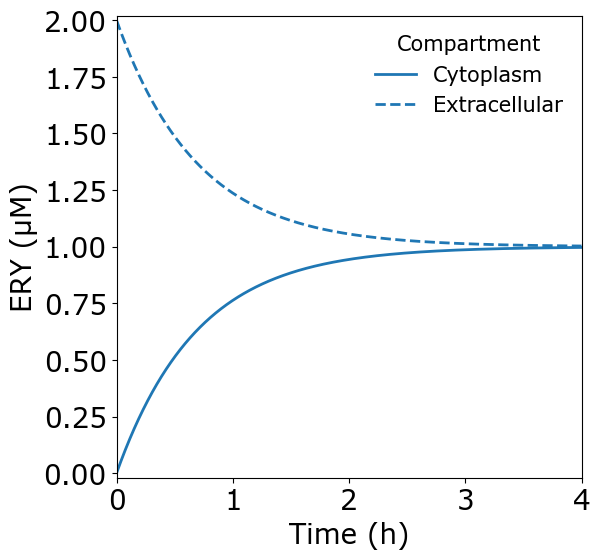

In [4]:
# Simulate: ERY Diffusion
try:
    # Inital conditions
    x0_dict= {'ERY_Extracellular':2}

    # Run Simulation
    R = CRN.simulate_with_bioscrape_via_sbml(timepoints = timepoints, initial_condition_dict = x0_dict)

    # Plot
    plt.plot(timepoints/3600,  R['ERY_Cytoplasm'], linewidth = 2, label = 'Cytoplasm', color = 'tab:blue')
    plt.plot(timepoints/3600,  R['ERY_Extracellular'], linewidth = 2, label = 'Extracellular', color='tab:blue', linestyle = 'dashed')

except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

FormatPlot(ylabel = 'ERY (μM)',ymax = 2, legend_label= 'Compartment')
# plt.savefig("simulation_figs/Figure_ERY_diffusion.svg")

# Example 2: Simple Transport

Integration of membrane protein (monomer) and simple transport by a membrane channel (ex. IPTG and $\alpha$-hemolysin)

<p align="center">
  <img src="./schematics/fig_alphaHL.png" alt="Simple_Transport" width="500"/>
</p>

Consider the following substrate transport steps:

1. Assemble into a homoheptamer:
   $$\begin{aligned}
     7 \text{$\alpha$HL}_\text{monomer} \rightarrow \text{$\alpha$HL}_\text{homoheptamer}
   \end{aligned}$$
2. Integration of membrane protein in membrane:
   $$\begin{aligned}
     \text{$\alpha$HL}_\text{homoheptamer} \rightarrow \text{$\alpha$HL}_\text{channel}
   \end{aligned}$$
3. Diffusion of small molecules (i.e. ATP) across membrane:
   $$\begin{aligned}
     \text{ATP}_\text{internal} + \text{$\alpha$HL}_\text{channel} \rightleftharpoons \text{ATP}_\text{external} + \text{$\alpha$HL}_\text{channel}
   \end{aligned}$$

## Compile CRN

In [5]:
# Packages
import biocrnpyler as bcp

# Components
alphaHL_monomer = bcp.IntegralMembraneProtein(
    membrane_protein = 'alphaHL_monomer',
    product = 'alphaHL',
    direction = 'Passive',
    size = 7,
    compartment = 'Cytoplasm',
    membrane_compartment = 'Membrane'
)

alphaHL_channel = bcp.MembraneChannel(
    integral_membrane_protein = alphaHL_monomer.product,
    substrate = 'ATP',
    internal_compartment = 'Cytoplasm',
    external_compartment= 'Extracellular'
)

# Mechanisms
mech_int = bcp.Membrane_Protein_Integration()
mech_tra = bcp.Simple_Transport()

# Create mixture
M = bcp.Mixture(
    "transport_alphaHL-ATP",
    components = [alphaHL_monomer, alphaHL_channel],
    mechanisms = {
        'membrane_insertion': mech_int,
        'transport': mech_tra
    },
    parameter_file = transport_params_dir,
)

# Compile the CRN with Mixture.compile_crn
CRN = M.compile_crn()
# CRN.write_sbml_file('models/alphaHL-atp_transport_model.xml')

# Print the compiled CRN
print(CRN.pretty_print(
    show_rates=True,
    show_attributes=True,
    show_materials=True,
    show_keys=False
))

Species(N = 5) = {
    complex[7x_protein[alphaHL_monomer]] (@ 0),  
    protein[alphaHL_monomer] (@ 0),  
    protein[alphaHL(Passive)] (@ 0),  
    ATP (@ 0),  
    ATP (@ 0),  
}

Reactions (3) = [
0. 7protein[alphaHL_monomer] <--> complex[7x_protein[alphaHL_monomer]]
 Kf=k_forward * protein_alphaHL_monomer_Cytoplasm^7
 Kr=k_reverse * complex_protein_alphaHL_monomer_7x_Cytoplasm_
  k_forward=0.002
  k_reverse=2e-10

1. complex[7x_protein[alphaHL_monomer]] --> protein[alphaHL(Passive)]
 Kf = k complex[7x_protein[alphaHL_monomer]] / ( 1 + (protein[alphaHL(Passive)]/K)^4 )
  k=10.0
  K=0.5
  n=4

2. ATP+protein[alphaHL(Passive)] <--> ATP+protein[alphaHL(Passive)]
 Kf=k_forward * ATP_Cytoplasm * protein_alphaHL_Passive_Membrane
 Kr=k_reverse * ATP_Extracellular * protein_alphaHL_Passive_Membrane
  k_forward=0.1
  k_reverse=0.1

]


## Simulate

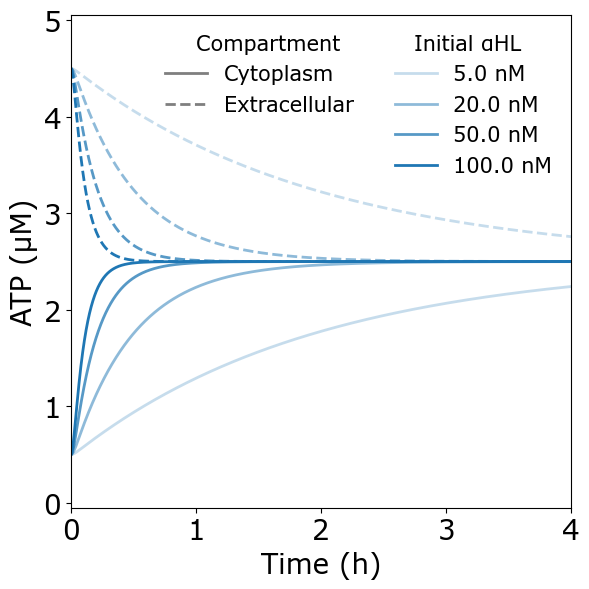

In [6]:
# Simulate CRN
try:
    from matplotlib.lines import Line2D

    # Monomer concentrations
    monomer_concentrations = [0.005, 0.02, 0.05, 0.1]

    # Set up the Figure Grid
    plt.figure(figsize=(6, 6))

    # Loop through each concentration, simulate, and plot the results
    for i, alpha_conc in enumerate(monomer_concentrations):

        # Calculate increasing transparency
        line_alpha = .25 + (0.25 * i)

        # Initial conditions
        x0_dict = {
            'protein_alphaHL_monomer_Cytoplasm': alpha_conc,
            'ATP_Extracellular': 4.5,
            'ATP_Cytoplasm': 0.5
        }

        # Run Simulation
        R = CRN.simulate_with_bioscrape_via_sbml(timepoints=timepoints, initial_condition_dict=x0_dict)

        # Passive Transport of ATP
        plt.plot(timepoints/3600, R['ATP_Cytoplasm'], linewidth=2, color='tab:blue',
                 alpha=line_alpha, label=f'{alpha_conc*1000} nM')

        plt.plot(timepoints/3600, R['ATP_Extracellular'], linewidth=2, color='tab:blue',
                 linestyle='dashed', alpha=line_alpha)

    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='solid', label='Cytoplasm')
    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='dashed', label='Extracellular')

    # Formatting
    FormatPlot(ylabel='ATP (μM)', ymax=5, legend_label='Initial αHL Monomer')

    # Format legend columns
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # Create an invisible "blank" handle to pad the right column
    empty_handle = Line2D([], [], linestyle='')
    empty_label = ''

    new_handles = [
        handles[4], handles[5], empty_handle, empty_handle,
        handles[0], handles[1], handles[2], handles[3],
    ]
    new_labels = [
        labels[4], labels[5], empty_label, empty_label,
        labels[0], labels[1], labels[2], labels[3],
    ]

    # Redraw the legend
    ax.legend(new_handles, new_labels, ncol=2, frameon = False,
              title = 'Compartment          Initial αHL',
              title_fontsize = 15, fontsize = 15, loc = 'best')

    plt.tight_layout()
    # plt.savefig("simulation_figs/Figure_alphaHL-ERY_transport.svg")
    plt.show()

except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

# Example 3: Facilitated Transport

Integration of membrane protein (homdimer) and facilitated transport by a membrane carrier (ex. glucose and GLUT1)

GLUT1: A Facilitated Passive Diffusion Protein modeled as a monomer (though can form dimers and tetrameter)

<p align="center">
  <img src="./schematics/fig_glut1.png" alt="Facilitated_Transport" width="500"/>
</p>

Consider the following substrate transport steps:

1. Integration of membrane protein in membrane:
   $$\begin{aligned}
     \text{GLUT1}_\text{monomer} \rightarrow \text{GLUT1}_\text{channel}
   \end{aligned}$$
2. Binding and transport of glucose across membrane:
   $$\begin{aligned}
     \text{glucose}_\text{external} + \text{GLUT1}_\text{channel} \rightarrow \text{glucose}_\text{external}:\text{GLUT1}_\text{channel} 
     \rightarrow \text{glucose}_\text{internal}:\text{GLUT1}_{channel}
   \end{aligned}$$
3. Unbinding glucose from transporter:
   $$\begin{aligned}
     \text{glucose}_\text{internal}:\text{GLUT1}_\text{channel} \rightarrow \text{glucose}_\text{internal} + \text{GLUT1}_\text{channel}
   \end{aligned}$$

## Compile CRN

In [7]:
# Packages
import biocrnpyler as bcp

# Components
glut1 = bcp.IntegralMembraneProtein(
    membrane_protein = 'glut1',
    product = 'glut1_channel',
    direction = 'Importer',
    size = 1,
    compartment = 'Cytoplasm',
    membrane_compartment = 'Membrane'
)

glut1_channel = bcp.MembraneChannel(
    integral_membrane_protein = glut1.product,
    substrate ='glucose',
    internal_compartment = 'Cytoplasm',
    external_compartment = 'Extracellular'
)

# Mechanisms
mech_int = bcp.Membrane_Protein_Integration()
mech_tra = bcp.Facilitated_Transport_MM()

# Create mixture
M= bcp.Mixture(
    "transport_GLLUT1-glucose",
    components = [glut1, glut1_channel],
    mechanisms = {
        'membrane_insertion': mech_int,
        'transport': mech_tra
    },
    parameter_file = transport_params_dir
)

# Compile the CRN with Mixture.compile_crn
CRN = M.compile_crn()
# CRN.write_sbml_file('models/GLLUT1-glucose_transport_model.xml')

# Print the compiled CRN
print(CRN.pretty_print(
    show_rates = True,
    show_attributes = True,
    show_materials = True,
    show_keys = False
))

Species(N = 6) = {
    protein[glut1_channel(Importer)] (@ 0),  
    protein[glut1] (@ 0),  
    complex[glucose:protein[glut1_channel]] (@ 0),  
    complex[glucose:protein[glut1_channel]] (@ 0),  
    glucose (@ 0),  
    glucose (@ 0),  
}

Reactions (5) = [
0. protein[glut1] --> protein[glut1_channel(Importer)]
 Kf = k protein[glut1] / ( 1 + (protein[glut1_channel(Importer)]/K)^4 )
  k=10.0
  K=0.5
  n=4

1. glucose+protein[glut1_channel(Importer)] --> complex[glucose:protein[glut1_channel]]
kb_subMC * glucose_Extracellular * protein_glut1_channel_Importer_Membrane * Heaviside(glucose_Extracellular-glucose_Cytoplasm) - kb_subMC * glucose_Cytoplasm * protein_glut1_channel_Importer_Membrane * Heaviside(glucose_Extracellular-glucose_Cytoplasm)
  kb_subMC=0.1

2. complex[glucose:protein[glut1_channel]] --> protein[glut1_channel(Importer)]+glucose
 Kf=k_forward * complex_glucose_Extracellular_protein_glut1_channel_Importer_Membrane_
  k_forward=0.1

3. complex[glucose:protein[glut1_chan

## Simulate

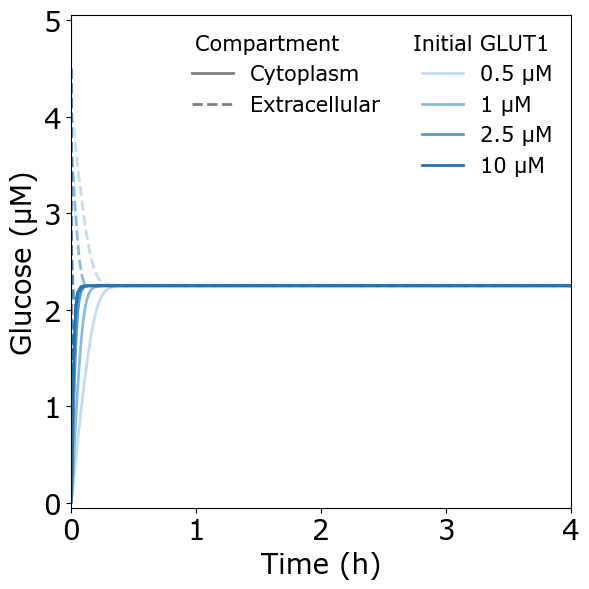

In [8]:
# Simulate CRN
try:
    from matplotlib.lines import Line2D

    # Monomer concentrations
    monomer_concentrations = [0.5, 1, 2.5, 10]

    # Set up the Figure Grid
    plt.figure(figsize=(6, 6))

    # Loop through each concentration, simulate, and plot the results
    for i, glut1_conc in enumerate(monomer_concentrations):

        # Calculate increasing transparency
        line_alpha = .25 + (0.25 * i)

        # Initial conditions
        x0_dict = {
            'protein_glut1_Cytoplasm': glut1_conc,
            'glucose_Extracellular': 4.5,
            'glucose_Cytoplasm': 0
        }

        # Run Simulation
        R = CRN.simulate_with_bioscrape_via_sbml(timepoints=timepoints, initial_condition_dict=x0_dict)

        # Facilitated Transport of glucose
        plt.plot(timepoints/3600, R['glucose_Cytoplasm'], linewidth=2, color='tab:blue',
                 alpha=line_alpha, label=f'{glut1_conc} μM')

        plt.plot(timepoints/3600, R['glucose_Extracellular'], linewidth=2, color='tab:blue',
                 linestyle='dashed', alpha=line_alpha)

    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='solid', label='Cytoplasm')
    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='dashed', label='Extracellular')

    # Formatting
    FormatPlot(ylabel='Glucose (μM)', ymax=5, legend_label='Initial GLUT1 Monomer')

    # Format legend columns
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # Create an invisible "blank" handle to pad the right column
    empty_handle = Line2D([], [], linestyle='')
    empty_label = ''

    new_handles = [
        handles[4], handles[5], empty_handle, empty_handle,
        handles[0], handles[1], handles[2], handles[3],
    ]
    new_labels = [
        labels[4], labels[5], empty_label, empty_label,
        labels[0], labels[1], labels[2], labels[3],
    ]

    # Redraw the legend
    ax.legend(new_handles, new_labels, ncol=2, frameon=False,
              title='Compartment          Initial GLUT1', # Spaced out title
              title_fontsize=15, fontsize=15, loc='best')

    plt.tight_layout()
    # plt.savefig("simulation_figs/Figure_GLUT1_transport.svg")
    plt.show()

except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

# Example 4: Primary Active Transport

Integration of membrane protein (homodimer) and active transport by a membrane pump (ex. Erythromycin (ERY) and MsbA)

<p align="center">
  <img src="./schematics/fig_msba.png" alt="Primary_Active_Transport" width="500"/>
</p>

Consider the following substrate transport steps:

2. Assemble into a homodimer:
   $$\begin{aligned}
    2 \text{MsbA}_\text{monomer} \rightarrow \text{MsbA}_\text{homodimer}
   \end{aligned}$$
3. Integration of membrane protein in membrane:
   $$\begin{aligned}
     \text{MsbA}_\text{homodimer} \rightarrow \text{MsbA}_\text{exporter}
   \end{aligned}$$
4. Binding of antibiotic (Abx) substrate (i.e. erythromycin) to MsbA transporter:
   $$\begin{aligned}
    \text{Abx}_\text{internal}+ \text{MsbA}_\text{exporter} \rightleftharpoons \text{Abx}_\text{internal}:\text{MsbA}_\text{exporter}
   \end{aligned}$$
5. Binding of ATP to complex of erythromycin with MsbA:
   $$\begin{aligned}
        2 \text{ATP}_\text{internal} + \text{Abx}_\text{internal}:\text{MsbA}_\text{exporter} \rightleftharpoons 2 \text{ATP}_\text{internal}:\text{Abx}_\text{internal}: \text{MsbA}_\text{exporter}
   \end{aligned}$$
6. Export of erythromycin lipid from inner membrane to outer membrane:
   $$\begin{aligned}
        2 \text{ATP}_\text{internal}:\text{Abx}_\text{internal}:\text{MsbA}_\text{exporter} \rightarrow 2 \text{ATP}_\text{internal}:\text{Abx}_\text{external}:\text{MsbA}_\text{transporter}
   \end{aligned}$$
7. Unbinding of erythromycin:
   $$\begin{aligned}
        2 \text{ATP}_\text{internal}:\text{Abx}_\text{external}:\text{MsbA}_\text{exporter} \rightarrow 2 \text{ADP}_\text{internal}:\text{MsbA}_\text{exporter} + \text{Abx}_\text{external}
   \end{aligned}$$
8. Unbinding of ADP with MsbA:
   $$\begin{aligned}
        2 \text{ADP}_\text{internal}:\text{MsbA}_\text{exporter} \rightarrow 2 \text{ADP}_\text{internal}:\text{MsbA}_\text{exporter}
   \end{aligned}$$

## Compile CRN

In [9]:
# Packages
import biocrnpyler as bcp

# Components
MsbA_monomer = bcp.IntegralMembraneProtein(
    membrane_protein = 'MsbA_monomer',
    product = 'MsbA_pump',
    size = 2,
    direction ='Exporter',
    compartment = 'Cytoplasm',
    membrane_compartment = 'Membrane'
)

MsbA_pump = bcp.MembranePump(
    membrane_pump = MsbA_monomer.product, # should this be changed to integral membrane protein?
    substrate = 'ERY',
    ATP = 2,
    internal_compartment = 'Cytoplasm',
    external_compartment = 'Extracellular'
)

# Mechanisms
mech_int = bcp.Membrane_Protein_Integration()
mech_tra = bcp.Primary_Active_Transport_MM()

# Create mixture
M = bcp.Mixture(
    'transport_Msba-ERY',
    components = [ERY, MsbA_monomer, MsbA_pump], # includes diffusion of ERY previously defined
    mechanisms = {
        'diffusion': mech_diff,
        'membrane_insertion': mech_int,
        'transport': mech_tra
    },
    parameter_file = [mixture_params_dir, transport_params_dir],
)

# Compile the CRN with Mixture.compile_crn
CRN = M.compile_crn()
# CRN.write_sbml_file('models/Msba-ERY_transport_model.xml')

# Print the compiled CRN
print(CRN.pretty_print(
    show_rates = True,
    show_attributes = True,
    show_materials = True,
    show_keys = False
))

Species(N = 11) = {
    small_molecule[ATP] (@ 600.0),  
    complex[protein[MsbA_pump]:2x_small_molecule[ADP]] (@ 0),  
    complex[2x_protein[MsbA_monomer]] (@ 0),  
    complex[complex[ERY:protein[MsbA_pump]]:2x_small_molecule[ATP]] (@ 0),  
    protein[MsbA_pump(Exporter)] (@ 0),  
    protein[MsbA_monomer] (@ 0),  
    complex[ERY:protein[MsbA_pump]:2x_small_molecule[ATP]] (@ 0),  
    complex[ERY:protein[MsbA_pump]] (@ 0),  
    ERY (@ 0),  
    ERY (@ 0),  
    small_molecule[ADP] (@ 0),  
}

Reactions (10) = [
0. ERY <--> ERY
 Kf=k_forward * ERY_Cytoplasm
 Kr=k_reverse * ERY_Extracellular
  k_forward=0.0002
  k_reverse=0.0002

1. 2protein[MsbA_monomer] <--> complex[2x_protein[MsbA_monomer]]
 Kf=k_forward * protein_MsbA_monomer_Cytoplasm^2
 Kr=k_reverse * complex_protein_MsbA_monomer_2x_Cytoplasm_
  k_forward=0.002
  k_reverse=2e-10

2. complex[2x_protein[MsbA_monomer]] --> protein[MsbA_pump(Exporter)]
 Kf = k complex[2x_protein[MsbA_monomer]] / ( 1 + (protein[MsbA_pump(Exporter

## Simulate

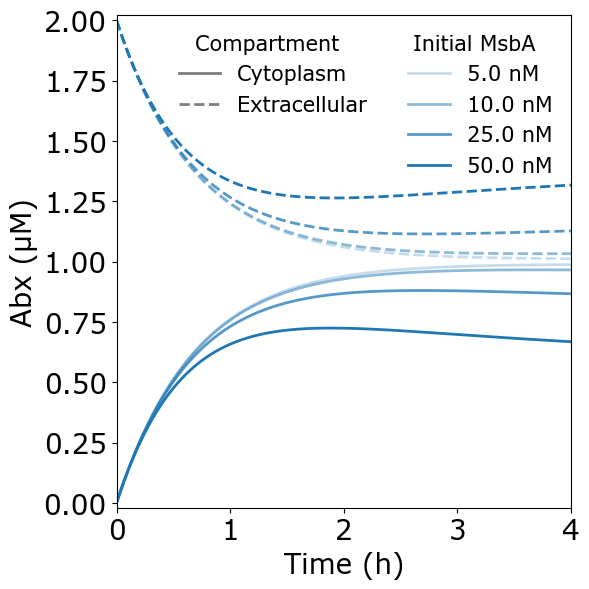

In [10]:
# Simulate CRN
try:
    from matplotlib.lines import Line2D

    # Monomer concentrations
    monomer_concentrations = [0.005, 0.01, 0.025, .05]

    # Set up the Figure Grid
    plt.figure(figsize=(6, 6))

    # Loop through each concentration, simulate, and plot the results
    for i, msba_conc in enumerate(monomer_concentrations):

        # Calculate increasing transparency
        line_alpha = .25 + (0.25 * i)

        # Initial conditions
        x0_dict = {
            'protein_MsbA_monomer_Cytoplasm':msba_conc,
            'ERY_Cytoplasm': 0,
            'ERY_Extracellular': 2,
            'small_molecule_ATP_Cytoplasm': 100
        }

        # Run Simulation
        R = CRN.simulate_with_bioscrape_via_sbml(timepoints=timepoints, initial_condition_dict=x0_dict)

        # Active Transport of Erythromycin (ERY)
        plt.plot(timepoints/3600, R['ERY_Cytoplasm'], linewidth=2, color='tab:blue',
                 alpha=line_alpha, label=f'{msba_conc*1000} nM')

        plt.plot(timepoints/3600, R['ERY_Extracellular'], linewidth=2, color='tab:blue',
                 linestyle='dashed', alpha=line_alpha)

    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='solid', label='Cytoplasm')
    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='dashed', label='Extracellular')

    # Formatting
    FormatPlot(ylabel='Abx (μM)', ymax=(R['ERY_Cytoplasm']+R['ERY_Extracellular']).max(), legend_label='Initial MsbA Monomer')

    # Format legend columns
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # Create an invisible "blank" handle to pad the right column
    empty_handle = Line2D([], [], linestyle='')
    empty_label = ''

    new_handles = [
        handles[4], handles[5], empty_handle, empty_handle,
        handles[0], handles[1], handles[2], handles[3],
    ]
    new_labels = [
        labels[4], labels[5], empty_label, empty_label,
        labels[0], labels[1], labels[2], labels[3],
    ]

    # Redraw the legend
    ax.legend(new_handles, new_labels, ncol=2, frameon=False,
              title='Compartment          Initial MsbA',
              title_fontsize=15, fontsize=15, loc='best')

    plt.tight_layout()
    # plt.savefig("simulation_figs/Figure_Msba-ERY_transport.svg")
    plt.show()

except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

# Example 5: Two Component Signaling (TCS)

Integration of membrane protein (homodimer) and two-component regulatory system (NarX/NarL). 

<p align="center">
  <img src="./schematics/fig_narxl.png" alt="Two_Component_Sensing" width="500"/>
</p>


Consider the following signal transduction pathways:
1. Assemble into a homodimer:
   $$\begin{aligned}
    2 \text{NarX}_\text{monomer} \rightarrow \text{NarX}_\text{homodimer}
   \end{aligned}$$
2. Integration of membrane protein in membrane:
   $$\begin{aligned}
    \text{NarX}_\text{homodimer} \rightarrow \text{NarX}_\text{sensor}
   \end{aligned}$$
3. Detecting and binding to nitrate (NO3):
   $$\begin{aligned}
    \text{NarX}_\text{sensor} +  \text{NO}_3 \rightleftharpoons \text{NarX}_\text{sensor}:\text{NO}_3 \equiv \text{NarX}^*_\text{sensor}
   \end{aligned}$$
4. Auto-phosphorylation membrane sensor (NarX):
   $$\begin{aligned}
    \text{NarX}^*_\text{sensor} +  2 \text{ATP}_\text{internal} \rightleftharpoons \text{NarX}^*_\text{sensor}:2 \text{ATP}_\text{internal} \rightarrow \text{NarX}^{*2 P_\text{i}}_\text{sensor}:2 \text{ADP}_\text{internal}\rightarrow \text{NarX}^{*2 P_\text{i}}_\text{sensor} + 2 \text{ADP}_\text{internal}
   \end{aligned}$$
5. Phosphorylation of response protein (NarL):
   $$\begin{aligned}
    \text{NarX}^{*2 P_\text{i}}_\text{sensor} + \text{NarL} \rightleftharpoons \text{NarX}^{*2 P_\text{i}}_\text{sensor}:\text{NarL} \rightarrow \text{NarX}^{*}_\text{sensor}:\text{NarL}^{*} \rightarrow \text{NarX}^{*}_\text{sensor} + \text{NarL}^{*}
   \end{aligned}$$
6. Dephosphorylation of phosphoryled response protein (NarL*):
   $$\begin{aligned}
    \text{NarL}^{*} \rightarrow  \text{NarL} + P_\text{i}
   \end{aligned}$$

## Compile CRN

In [11]:
# Packages
import biocrnpyler as bcp

# Components
NO3 = bcp.Species(
    name = 'NO3',
    compartment = 'Extracellular')

NarX_monomer = bcp.IntegralMembraneProtein(
    membrane_protein = 'NarX_monomer',
    product = 'NarX',
    size = 2,
    compartment = 'Cytoplasm',
    membrane_compartment = 'Membrane'
)

NarX_sensor=bcp.MembraneSensor(
    membrane_sensor_protein = NarX_monomer.product,
    response_protein = 'NarL',
    assigned_substrate = 'P',
    signal_substrate = NO3,
    ATP = 2,
    internal_compartment = 'Cytoplasm',
    external_compartment = 'Extracellular'
)

# Mechanisms
mech_int = bcp.Membrane_Protein_Integration()
mech_sig = bcp.Membrane_Signaling_Pathway_MM()

# Create mixture
M = bcp.Mixture(
    "Signal_Narx-L",
    components = [NarX_monomer, NarX_sensor],
    mechanisms = {
        'membrane_insertion': mech_int,
        'membrane_sensor': mech_sig
    },
    parameter_file = transport_params_dir
    )

# Compile the CRN with Mixture.compile_crn
CRN = M.compile_crn()
# CRN.write_sbml_file('models/NarXL_signal_model.xml')

# Print the compiled CRN
print(CRN.pretty_print(
    show_rates = True,
    show_attributes = True,
    show_materials = True,
    show_keys = False
))

Species(N = 15) = {
    complex[2x_protein[NarX_monomer]] (@ 0),  
    complex[complex[NO3:protein[NarX]]:2x_small_molecule[ATP]] (@ 0),  
    complex[P:complex[NO3:protein[NarX]]:2x_small_molecule[ADP]] (@ 0),  
    complex[P:complex[NO3:protein[NarX]]] (@ 0),  
    P (@ 0),  
    protein[NarX_monomer] (@ 0),  
    protein[NarX(Passive)] (@ 0),  
    NarLactive (@ 0),  
    complex[NarL:complex[P:complex[NO3:protein[NarX]]]] (@ 0),  
    complex[NarL:P:complex[NO3:protein[NarX]]] (@ 0),  
    NarL (@ 0),  
    complex[NO3:protein[NarX]] (@ 0),  
    NO3 (@ 0),  
    small_molecule[ATP] (@ 0),  
    small_molecule[ADP] (@ 0),  
}

Reactions (10) = [
0. 2protein[NarX_monomer] <--> complex[2x_protein[NarX_monomer]]
 Kf=k_forward * protein_NarX_monomer_Cytoplasm^2
 Kr=k_reverse * complex_protein_NarX_monomer_2x_Cytoplasm_
  k_forward=0.002
  k_reverse=2e-10

1. complex[2x_protein[NarX_monomer]] --> protein[NarX(Passive)]
 Kf = k complex[2x_protein[NarX_monomer]] / ( 1 + (protein[NarX(Pass

## Simulate

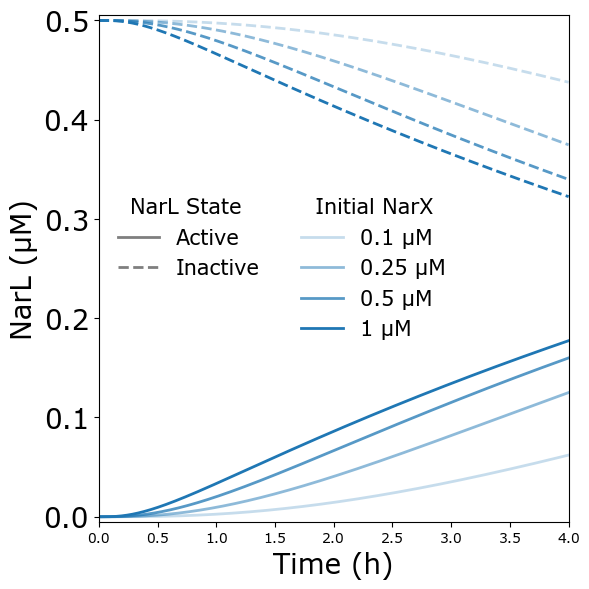

In [12]:
# Simulate CRN
try:
    from matplotlib.lines import Line2D

    # Monomer concentrations
    monomer_concentrations = [0.1, 0.25, .5, 1]

    # Set up the Figure Grid
    plt.figure(figsize=(6, 6))

    # Loop through each concentration, simulate, and plot the results
    for i, narx_conc in enumerate(monomer_concentrations):

        # Calculate increasing transparency
        line_alpha = .25 + (0.25 * i)

        # Initial conditions
        x0_dict = {
            'protein_NarX_monomer_Cytoplasm':narx_conc,
            'NO3_Extracellular': 0.02,
            'NarL_Cytoplasm': 0.5,
            'small_molecule_ATP_Cytoplasm': 3
        }

        # Run Simulation
        R = CRN.simulate_with_bioscrape_via_sbml(timepoints=timepoints, initial_condition_dict=x0_dict)

        # Activation of NarL
        plt.plot(timepoints/3600, R['NarLactive_Cytoplasm'], linewidth=2, color='tab:blue',
                 alpha=line_alpha, label=f'{narx_conc} μM')

        plt.plot(timepoints/3600, R['NarL_Cytoplasm'], linewidth=2, color='tab:blue',
                 linestyle='dashed', alpha=line_alpha)

    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='solid', label='Active')
    plt.plot([], [], color='tab:gray', linewidth=2, linestyle='dashed', label='Inactive')

    # Formatting
    FormatPlot(ylabel='NarL (μM)', ymax=R['NarL_Cytoplasm'].max(), legend_label='Initial NarX Monomer')

    # Format legend columns
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # Create an invisible "blank" handle to pad the right column
    empty_handle = Line2D([], [], linestyle='')
    empty_label = ''

    new_handles = [
        handles[4], handles[5], empty_handle, empty_handle,
        handles[0], handles[1], handles[2], handles[3],
    ]
    new_labels = [
        labels[4], labels[5], empty_label, empty_label,
        labels[0], labels[1], labels[2], labels[3],
    ]

    # Redraw the legend
    ax.legend(new_handles, new_labels, ncol=2, frameon=False,
              title='NarL State          Initial NarX',
              title_fontsize=15, fontsize=15, loc='best')

    plt.tight_layout()
    # plt.savefig("simulation_figs/Figure_NarXL_transport.svg")
    plt.show()

except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

# Computing environment

In [13]:
%load_ext watermark
%watermark -v -p bioscrape,bokeh,jupyterlab,biocrnpyler

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.15.0

bioscrape  : 1.4.0
bokeh      : 3.8.1
jupyterlab : 4.5.0
biocrnpyler: 1.3.3

